# 데이터 컬럼 처리

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
df = pd.read_excel('/content/drive/MyDrive/data/step2_1_수정2.xlsx')

In [ ]:
df.columns

Index(['암호화요양기호', '요양기관명', '종별코드명', '시도코드명', '시군구코드명', '읍면동', '총의사수',
       '의과일반의 인원수', '의과인턴 인원수', '의과레지던트 인원수', '의과전문의 인원수', '치과일반의 인원수',
       '치과인턴 인원수', '치과레지던트 인원수', '치과전문의 인원수', '한방일반의 인원수', '한방인턴 인원수',
       '한방레지던트 인원수', '한방전문의 인원수', '조산사 인원수', '좌표(X)', '좌표(Y)', '설립구분코드명',
       '일반입원실상급병상수', '일반입원실일반병상수', '성인중환자병상수', '소아중환자병상수', '신생아중환자병상수',
       '분만실병상수', '수술실병상수', '응급실병상수', '물리치료실병상수', '정신과폐쇄상급병상수', '정신과폐쇄일반병상수',
       '격리병실병상수', '무균치료실병상수', '진료과목코드명', '과목별 전문의수', '선택진료 의사수', '유형코드명',
       '간호등급', '기타인력코드명', '기타인력수'],
      dtype='object')

In [ ]:
dfc = df.drop(['암호화요양기호', '종별코드명', '시도코드명', '시군구코드명', '읍면동', '총의사수',
       '의과일반의 인원수', '의과인턴 인원수', '의과레지던트 인원수', '의과전문의 인원수', '치과일반의 인원수',
       '치과인턴 인원수', '치과레지던트 인원수', '치과전문의 인원수', '한방일반의 인원수', '한방인턴 인원수',
       '한방레지던트 인원수', '한방전문의 인원수', '조산사 인원수', '설립구분코드명',
       '일반입원실상급병상수', '일반입원실일반병상수', '성인중환자병상수', '소아중환자병상수', '신생아중환자병상수',
       '분만실병상수', '수술실병상수', '응급실병상수', '물리치료실병상수', '정신과폐쇄상급병상수', '정신과폐쇄일반병상수',
       '격리병실병상수', '무균치료실병상수', '진료과목코드명', '과목별 전문의수', '선택진료 의사수', '유형코드명',
       '간호등급', '기타인력코드명', '기타인력수'], axis = 1)
dfc.head()

,요양기관명,좌표(X),좌표(Y)
0,동서요양병원,127.021670,37.291190
1,동서요양병원,127.021670,37.291190
2,메이저요양병원,127.027345,37.275691
3,메이저요양병원,127.027345,37.275691
4,메이저요양병원,127.027345,37.275691


In [ ]:
dfc = dfc.drop_duplicates()
dfc.head()

,요양기관명,좌표(X),좌표(Y)
0,동서요양병원,127.021670,37.291190
2,메이저요양병원,127.027345,37.275691
6,서울삼성호매실요양병원,126.942959,37.273453
10,수원브이아이피요양병원,127.001078,37.270962
11,수원삼성요양병원,127.001252,37.293594


In [ ]:
dfc.to_csv('병원좌표.csv', index=False)

# 접근성_지하철

In [ ]:
import pandas as pd
from geopy.distance import geodesic

# 병원 좌표 데이터 불러오기
hospital_data = pd.read_csv('/content/drive/MyDrive/data/병원좌표.csv')

# 지하철역 좌표 데이터 불러오기
subway_data = pd.read_csv('/content/drive/MyDrive/data/suwon_subway (1).csv')

# 각 병원에 대해 가장 가까운 지하철역과의 거리를 계산하는 함수
def find_nearest_station(hospital_coords, stations):
    min_distance = float('inf')
    nearest_station = None

    for _, station in stations.iterrows():
        station_coords = (station['lat'], station['lng'])
        distance = geodesic(hospital_coords, station_coords).meters

        if distance < min_distance:
            min_distance = distance
            nearest_station = station['name']

    return nearest_station, min_distance

# 결과를 저장할 리스트
results = []

# 병원 데이터에 대해 가장 가까운 지하철역 찾기
for _, hospital in hospital_data.iterrows():
    hospital_coords = (hospital['좌표(Y)'], hospital['좌표(X)'])
    nearest_station, distance = find_nearest_station(hospital_coords, subway_data)

    results.append({
        "병원명": hospital['요양기관명'],
        "가장 가까운 지하철역": nearest_station,
        "거리(m)": distance
    })

# 결과를 데이터프레임으로 변환
nearest_station_df = pd.DataFrame(results)

# 결과 확인
nearest_station_df

,병원명,가장 가까운 지하철역,거리(m)
0,동서요양병원,광교,2357.984439
1,메이저요양병원,매교,1534.501485
2,서울삼성호매실요양병원,성균관대,3870.844162
3,수원브이아이피요양병원,수원,563.803290
4,수원삼성요양병원,화서,1493.047471
5,수원센트럴요양병원,성균관대,3255.891670
6,수원요양병원,영통,1192.719798
7,연세수요양병원,화서,2515.663834
8,연세엘림요양병원,화서,2016.281412
9,영통효요양병원,망포,940.144217


In [ ]:
import numpy as np

# 거리 데이터를 정규화합니다.
def normalize_column(column):
    norm_column = (column - column.min()) / (column.max() - column.min())
    return norm_column

# 거리를 정규화합니다.
nearest_station_df['정규화된 거리'] = normalize_column(nearest_station_df['거리(m)'])

# 이상적 해 (Ideal Solution) 및 최악의 해 (Anti-Ideal Solution) 결정
ideal_solution = 0  # 정규화된 거리 중 최소값 (최단 거리)
anti_ideal_solution = 1  # 정규화된 거리 중 최대값 (최장 거리)

# 이상적 해와의 거리 및 최악의 해와의 거리 계산
nearest_station_df['이상적 해와의 거리'] = np.abs(nearest_station_df['정규화된 거리'] - ideal_solution)
nearest_station_df['최악의 해와의 거리'] = np.abs(nearest_station_df['정규화된 거리'] - anti_ideal_solution)

# TOPSIS 점수 계산
nearest_station_df['TOPSIS 점수'] = nearest_station_df['최악의 해와의 거리'] / (nearest_station_df['이상적 해와의 거리'] + nearest_station_df['최악의 해와의 거리'])

# 최종 점수에 따라 병원 순위 정렬
nearest_station_df = nearest_station_df.sort_values(by='TOPSIS 점수', ascending=False)

# 결과를 확인합니다.
nearest_station_df[['병원명', '거리(m)', '정규화된 거리', 'TOPSIS 점수']]

,병원명,거리(m),정규화된 거리,TOPSIS 점수
3,수원브이아이피요양병원,563.803290,0.000000,1.000000
9,영통효요양병원,940.144217,0.113800,0.886200
11,학교법인 대우학원 아주대학교요양병원,1073.572128,0.154147,0.845853
10,위더스요양병원,1118.435998,0.167713,0.832287
6,수원요양병원,1192.719798,0.190175,0.809825
13,효정요양병원,1448.834885,0.267620,0.732380
4,수원삼성요양병원,1493.047471,0.280990,0.719010
1,메이저요양병원,1534.501485,0.293525,0.706475
8,연세엘림요양병원,2016.281412,0.439208,0.560792
0,동서요양병원,2357.984439,0.542534,0.457466


In [ ]:
import pandas as pd
from geopy.distance import geodesic
import folium

# 병원 좌표 데이터 불러오기
hospital_data = pd.read_csv('/content/drive/MyDrive/data/병원좌표.csv')

# 지하철역 좌표 데이터 불러오기
subway_data = pd.read_csv('/content/drive/MyDrive/data/suwon_subway (1).csv')

# 각 병원에 대해 가장 가까운 지하철역과의 거리를 계산하는 함수
def find_nearest_station(hospital_coords, stations):
    min_distance = float('inf')
    nearest_station = None
    nearest_station_coords = None

    for _, station in stations.iterrows():
        station_coords = (station['lat'], station['lng'])
        distance = geodesic(hospital_coords, station_coords).meters

        if distance < min_distance:
            min_distance = distance
            nearest_station = station['name']
            nearest_station_coords = station_coords

    return nearest_station, nearest_station_coords, min_distance

# 결과를 저장할 리스트
results = []

# 병원 데이터에 대해 가장 가까운 지하철역 찾기
for _, hospital in hospital_data.iterrows():
    hospital_coords = (hospital['좌표(Y)'], hospital['좌표(X)'])
    nearest_station, nearest_station_coords, distance = find_nearest_station(hospital_coords, subway_data)

    results.append({
        "병원명": hospital['요양기관명'],
        "병원좌표": hospital_coords,
        "가장 가까운 지하철역": nearest_station,
        "지하철역좌표": nearest_station_coords,
        "거리(m)": distance
    })

# 결과를 데이터프레임으로 변환
nearest_station_df = pd.DataFrame(results)

# 지도 생성 (수원 중심 좌표로 설정)
map_center = [37.291190, 127.021670]  # 대략적인 수원 중심 좌표
map_ = folium.Map(location=map_center, zoom_start=12)

# 병원과 지하철역, 그리고 둘 사이의 거리 표시
for _, row in nearest_station_df.iterrows():
    # 병원 마커 추가
    folium.Marker(
        location=row['병원좌표'],
        popup=f"병원: {row['병원명']}\n가장 가까운 지하철역: {row['가장 가까운 지하철역']}\n거리: {row['거리(m)']:.2f} m",
        icon=folium.Icon(color='blue', icon='info-sign')
    ).add_to(map_)

    # 지하철역 마커 추가
    folium.Marker(
        location=row['지하철역좌표'],
        popup=f"지하철역: {row['가장 가까운 지하철역']}\n거리: {row['거리(m)']:.2f} m",
        icon=folium.Icon(color='green', icon='train')
    ).add_to(map_)

    # 병원과 지하철역 사이 선 연결
    folium.PolyLine(locations=[row['병원좌표'], row['지하철역좌표']], color='red').add_to(map_)

# 지도를 HTML 파일로 저장
map_.save('/content/drive/MyDrive/data/hospital_accessibility_map.html')

# 지도 표시
map_

In [ ]:
import pandas as pd
from geopy.distance import geodesic
import folium
from folium.plugins import MarkerCluster

# 병원 좌표 데이터 불러오기
hospital_data = pd.read_csv('/content/drive/MyDrive/data/병원좌표.csv')

# 지하철역 좌표 데이터 불러오기
subway_data = pd.read_csv('/content/drive/MyDrive/data/suwon_subway (1).csv')

# 각 병원에 대해 가장 가까운 지하철역과의 거리를 계산하는 함수
def find_nearest_station(hospital_coords, stations):
    min_distance = float('inf')
    nearest_station = None
    nearest_station_coords = None

    for _, station in stations.iterrows():
        station_coords = (station['lat'], station['lng'])
        distance = geodesic(hospital_coords, station_coords).meters

        if distance < min_distance:
            min_distance = distance
            nearest_station = station['name']
            nearest_station_coords = station_coords

    return nearest_station, nearest_station_coords, min_distance

# 결과를 저장할 리스트
results = []

# 병원 데이터에 대해 가장 가까운 지하철역 찾기
for _, hospital in hospital_data.iterrows():
    hospital_coords = (hospital['좌표(Y)'], hospital['좌표(X)'])
    nearest_station, nearest_station_coords, distance = find_nearest_station(hospital_coords, subway_data)

    results.append({
        "병원명": hospital['요양기관명'],
        "병원좌표": hospital_coords,
        "가장 가까운 지하철역": nearest_station,
        "지하철역좌표": nearest_station_coords,
        "거리(m)": distance
    })

# 결과를 데이터프레임으로 변환
nearest_station_df = pd.DataFrame(results)

# 지도 생성 (수원 중심 좌표로 설정, 깔끔한 타일 스타일 적용)
map_center = [37.291190, 127.021670]  # 대략적인 수원 중심 좌표
map_ = folium.Map(location=map_center, zoom_start=12, tiles='cartodb positron')

# 마커 클러스터링 추가
marker_cluster = MarkerCluster().add_to(map_)

# 병원과 지하철역, 그리고 둘 사이의 거리 표시
for _, row in nearest_station_df.iterrows():
    # 병원 마커 추가
    folium.Marker(
        location=row['병원좌표'],
        popup=folium.Popup(f"<b>병원:</b> {row['병원명']}<br><b>가장 가까운 지하철역:</b> {row['가장 가까운 지하철역']}<br><b>거리:</b> {row['거리(m)']:.2f} m", max_width=300),
        icon=folium.Icon(color='darkblue', icon='plus', prefix='fa')
    ).add_to(marker_cluster)

    # 지하철역 마커 추가
    folium.Marker(
        location=row['지하철역좌표'],
        popup=folium.Popup(f"<b>지하철역:</b> {row['가장 가까운 지하철역']}<br><b>거리:</b> {row['거리(m)']:.2f} m", max_width=300),
        icon=folium.Icon(color='green', icon='subway', prefix='fa')
    ).add_to(marker_cluster)

    # 병원과 지하철역 사이 선 연결
    folium.PolyLine(locations=[row['병원좌표'], row['지하철역좌표']], color='red', weight=2.5, opacity=0.7).add_to(map_)

# 지도를 HTML 파일로 저장
map_.save('/content/drive/MyDrive/data/hospital_accessibility_map.html')

# 지도 표시
map_


# 지도 표시

In [ ]:
import pandas as pd
import folium
import requests

# 한국 지도의 중심 좌표 설정 (예: 서울)
map_korea = folium.Map(location=[37.2635727,127.0286009], zoom_start=12)

# 데이터프레임의 각 행에 대해 마커 추가
for idx, row in dfc.iterrows():
    if not pd.isnull(row['좌표(X)']) and not pd.isnull(row['좌표(Y)']):
        folium.Marker(
            location=[row['좌표(Y)'], row['좌표(X)']],  # 위도(Y), 경도(X) 순서로 수정
            popup=row['요양기관명'],
            tooltip=row['요양기관명'],
        ).add_to(map_korea)

# 대체 수원시 GeoJSON 경계 데이터 가져오기
url = "https://raw.githubusercontent.com/johan/world.geo.json/master/countries/KOR.geo.json"
geojson_data = requests.get(url).json()

# GeoJSON에서 수원시의 경계만 필터링
suwon_geojson = {
    "type": "FeatureCollection",
    "features": [
        feature for feature in geojson_data["features"]
        if "Suwon" in feature["properties"]["name"]
    ]
}

# 수원시 경계를 지도에 추가
folium.GeoJson(
    suwon_geojson,
    name="Suwon Boundary"
).add_to(map_korea)

# 지도를 출력
map_korea

In [ ]:
m_grid = folium.Map(location= [37.2635727,127.0286009],tiles = 'OpenStreetMap' , zoom_start = 11)

In [ ]:
! pip install haversine

In [ ]:
from haversine import inverse_haversine, Direction
from math import pi

In [ ]:
def get_bound (coordinate):
  north = inverse_haversine(coordinate, 25, Direction.NORTH, unit='m')
  up_right = inverse_haversine(north, 25, Direction.EAST, unit='m')

  south = inverse_haversine(coordinate, 25, Direction.SOUTH, unit='m')
  dn_left = inverse_haversine(south, 25, Direction.WEST, unit='m')

  return [up_right,dn_left]

In [ ]:
get_bound((37.2635727,127.0286009))

[(37.26379752975534, 127.02888340089159),
 (37.26334786957347, 127.02831840079516)]

In [ ]:
import folium
import numpy as np

# 지도 중심과 줌 레벨 설정
map_center = [37.2635727,127.0286009]  # 수원 중심 좌표
zoom_start = 12

# 지도 생성
m = folium.Map(location=map_center, zoom_start=zoom_start)

# 격자 크기 설정 (경도, 위도 단위로 1단위는 약 111km)
grid_size = 0.01  # 1km 정도의 격자 크기

# 격자 그리기
for lat in np.arange(map_center[0] - 1, map_center[0] + 1, grid_size):
    for lon in np.arange(map_center[1] - 1, map_center[1] + 1, grid_size):
        # 사각형의 각 점 정의
        bounds = [[lat, lon], [lat + grid_size, lon + grid_size]]

        # 사각형 추가
        folium.Rectangle(bounds=bounds, color='blue', fill=False, weight=1).add_to(m)

# 지도 저장
m.save('grid_map.html')

# 새 섹션

In [ ]:
import geopandas as gpd

# GPKG 파일 읽기
gdf = gpd.read_file("/content/drive/MyDrive/data/SUWON_HANGJUNGDONG.gpkg", encoding = 'cp949')

# 데이터 확인
print(gdf.head())

     EMD_CD       EMD_ENG_NM EMD_KOR_NM  \
0  41111129      Pajang-dong       ���嵿   
1  41111130     Jeongja-dong      ���ڵ�   
2  41111131        Imok-dong      �̸���   
3  41111132     Yuljeon-dong     ������   
4  41111133  Cheoncheon-dong       õõ��   

                                            geometry  
0  MULTIPOLYGON (((956654.42140 1924567.43636, 95...  
1  MULTIPOLYGON (((954539.60880 1923733.72199, 95...  
2  MULTIPOLYGON (((954024.02523 1925442.83471, 95...  
3  MULTIPOLYGON (((953427.46702 1923418.07941, 95...  
4  MULTIPOLYGON (((954068.12503 1923156.23511, 95...  


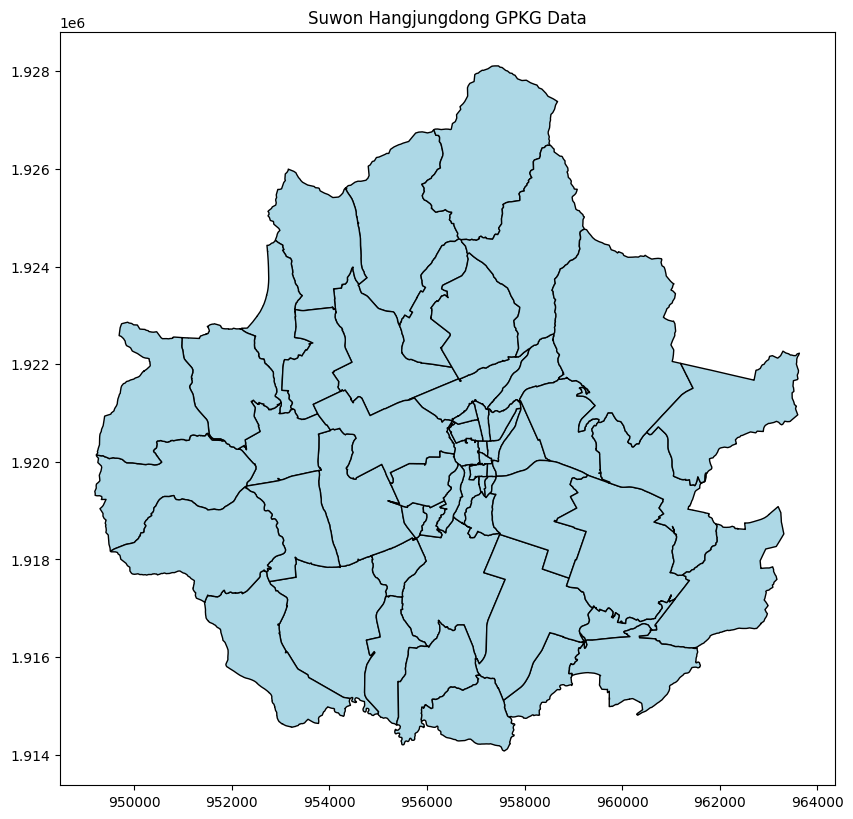

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))
gdf.plot(ax=ax, color='lightblue', edgecolor='black')
ax.set_title('Suwon Hangjungdong GPKG Data')
plt.show()

In [ ]:
! pip install contextily

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.5/21.5 MB 56.0 MB/s eta 0:00:00


AttributeError: Stamen

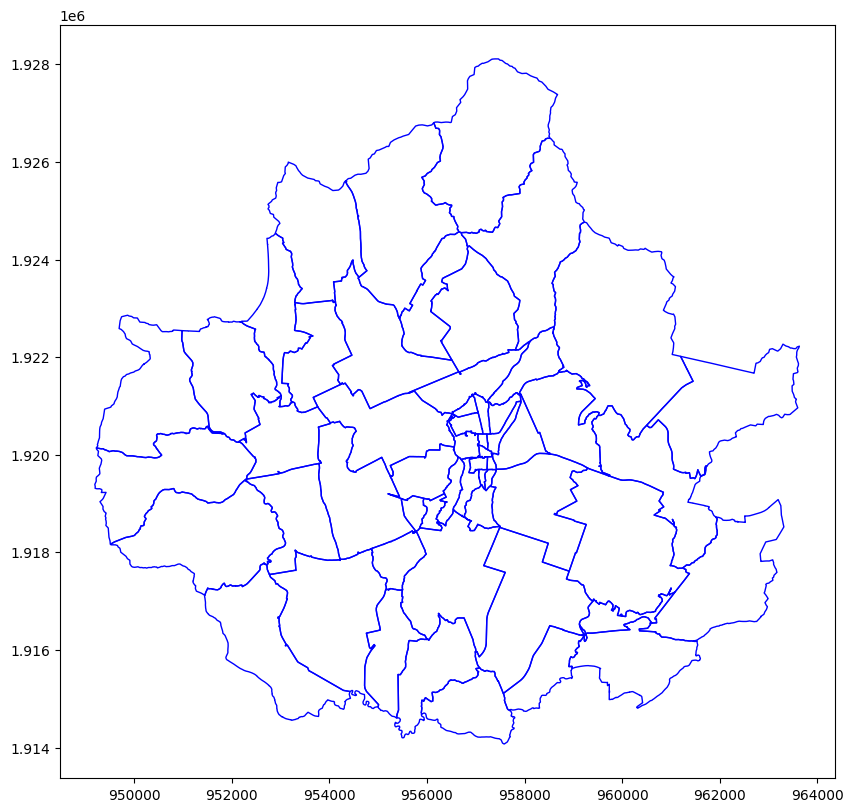

In [ ]:
import geopandas as gpd
import contextily as ctx
import matplotlib.pyplot as plt

# Convert multi-part geometries to single-part geometries
gdf = gdf.explode(ignore_index=True)

# Set the coordinate reference system (CRS) to Web Mercator for basemap compatibility


# Plot the data with a basemap
fig, ax = plt.subplots(figsize=(10, 10))
gdf.plot(ax=ax, color='none', edgecolor='blue')  # Plot the GPKG data with no fill and blue edges

# Add basemap
ctx.add_basemap(ax, source=ctx.providers.Stamen.TonerLite)

plt.title("Suwon Hangjungdong Overlaid on Basemap")
plt.show()

In [ ]:
import geopandas as gpd
import contextily as ctx
import matplotlib.pyplot as plt

# GeoPackage 파일 불러오기

print("Original CRS:", gdf.crs)

# 만약 CRS가 정의되지 않았다면, EPSG:4326으로 설정 (WGS84)
if gdf.crs is None:
    gdf = gdf.set_crs(epsg=4326)

# CRS를 Web Mercator로 변환 (EPSG:3857)
gdf = gdf.to_crs(epsg=3857)

# 멀티폴리곤을 개별 폴리곤으로 분해
gdf = gdf.explode(ignore_index=True)

# 데이터 시각화 (베이스맵과 함께)
fig, ax = plt.subplots(figsize=(10, 10))
gdf.plot(ax=ax, color='none', edgecolor='blue')  # 파란색 테두리로 GPKG 데이터 시각화

# 베이스맵 추가
ctx.add_basemap(ax, source=ctx.providers.Stamen.TonerLite)

plt.title("Suwon Hangjungdong Overlaid on Basemap")
plt.show()

Original CRS: LOCAL_CS["Undefined SRS",LOCAL_DATUM["unknown",32767],UNIT["unknown",0],AXIS["Easting",EAST],AXIS["Northing",NORTH]]


ProjError: Error creating Transformer from CRS.

# 새 섹션

In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# GeoPackage 파일과 CSV 파일 불러오기
gdf = gpd.read_file('/content/drive/MyDrive/data/SUWON_HANGJUNGDONG.gpkg')
csv_data = pd.read_csv('/content/drive/MyDrive/data/행정동별_노인수.csv')

# GeoDataFrame과 DataFrame 병합 (행정동 이름을 기준으로)
merged = gdf.merge(csv_data, left_on='행정동명', right_on='행정구역(동읍면)별')

# 노인수를 기준으로 색깔 표현
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
merged.plot(column='노인수', cmap='OrRd', linewidth=0.8, ax=ax, edgecolor='0.8', legend=True)

# 제목 추가
ax.set_title('수원시 행정동별 노인 인구수 분포', fontsize=15)
ax.axis('off')

# 결과 출력
plt.show()

KeyError: '행정동명'

In [ ]:
import pandas as pd

# CSV 파일 불러오기


# 한글 행정동명을 영어로 변환하는 매핑 사전 (예시)
mapping = {
    "파장동": "Pajang-dong",
    "송죽동": "Songjuk-dong",
    "율천동": "Yulcheon-dong",
    "정자동": "Jeongja-dong",
    "고등동": "Godeung-dong",
    "매교동": "Maegyo-dong",
    "화서동": "Hwaseo-dong",
    "행궁동": "Haenggung-dong",
    "영화동": "Yeonghwa-dong",
    "인계동": "Ingyedong",
     '정자1동': 'Jeongja 1-dong',
    '정자2동': 'Jeongja 2-dong',
    '정자3동': 'Jeongja 3-dong',
    '조원1동': 'Jowon 1-dong',
    '조원2동': 'Jowon 2-dong',
    '연무동': 'Yeonmu-dong',
    '세류1동': 'Seryu 1-dong',
    '세류2동': 'Seryu 2-dong',
    '세류3동': 'Seryu 3-dong',
    '평동': 'Pyeong-dong',
    '서둔동': 'Seodun-dong',
    '구운동': 'Guun-dong',
    '금곡동': 'Geumgok-dong',
    '호매실동': 'Homaesil-dong',
    '권선1동': 'Gwonseon 1-dong',
    '권선2동': 'Gwonseon 2-dong',
    '곡선동': 'Gokseon-dong',
    '입북동': 'Ipbuk-dong',
    '매산동': 'Maesan-dong',
    '화서1동': 'Hwaseo 1-dong',
    '화서2동': 'Hwaseo 2-dong',
    '지동': 'Ji-dong',
    '우만1동': 'Uman 1-dong',
    '우만2동': 'Uman 2-dong',
    '매탄1동': 'Maetan 1-dong',
    '매탄2동': 'Maetan 2-dong',
    '매탄3동': 'Maetan 3-dong',
    '매탄4동': 'Maetan 4-dong',
    '원천동': 'Woncheon-dong',
    '영통1동': 'Yeongtong 1-dong',
    '영통2동': 'Yeongtong 2-dong',
    '영통3동': 'Yeongtong 3-dong',
    '망포1동': 'Mangpo 1-dong',
    '망포2동': 'Mangpo 2-dong',
    '광교1동': 'Gwanggyo 1-dong',
    '광교2동': 'Gwanggyo 2-dong'
    # 여기에 나머지 행정동 매핑을 추가
}

# CSV 파일의 '행정구역(동읍면)별' 컬럼을 영어로 변환
csv_data['emd_eng_nm'] = csv_data['행정구역(동읍면)별'].map(mapping)

# 매핑되지 않은 값이 있는지 확인 (만약 있다면 None 값이 출력됨)
unmapped = csv_data[csv_data['emd_eng_nm'].isnull()]['행정구역(동읍면)별'].unique()

print("매핑되지 않은 행정동:", unmapped)

# 결과 확인
csv_data.head()

매핑되지 않은 행정동: []


,행정구역(동읍면)별,노인수,emd_eng_nm
0,파장동,4717,Pajang-dong
1,율천동,4974,Yulcheon-dong
2,정자1동,4550,Jeongja 1-dong
3,정자2동,5483,Jeongja 2-dong
4,정자3동,3804,Jeongja 3-dong


In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import Polygon, MultiPolygon

# GeoPackage 파일 불러오기
gdf = gpd.read_file('/content/drive/MyDrive/data/SUWON_HANGJUNGDONG.gpkg')

def multipart_to_singlepart(geom):
    if isinstance(geom, MultiPolygon):
        return [Polygon(p.exterior.coords) for p in geom]
    else:
        return geom

# GeoDataFrame에서 geometry 컬럼 처리
gdf['geometry'] = gdf['geometry'].apply(multipart_to_singlepart)
gdf = gdf.explode(ignore_index=True)

# CSV 파일 불러오기
csv_data = pd.read_csv('/content/drive/MyDrive/data/행정동별_노인수.csv')

# 한글 행정동명을 영어로 변환하는 매핑 사전
mapping = {
    '정자1동': 'Jeongja 1-dong',
    '정자2동': 'Jeongja 2-dong',
    '정자3동': 'Jeongja 3-dong',
    '조원1동': 'Jowon 1-dong',
    '조원2동': 'Jowon 2-dong',
    '연무동': 'Yeonmu-dong',
    '세류1동': 'Seryu 1-dong',
    '세류2동': 'Seryu 2-dong',
    '세류3동': 'Seryu 3-dong',
    '평동': 'Pyeong-dong',
    '서둔동': 'Seodun-dong',
    '구운동': 'Guun-dong',
    '금곡동': 'Geumgok-dong',
    '호매실동': 'Homaesil-dong',
    '권선1동': 'Gwonseon 1-dong',
    '권선2동': 'Gwonseon 2-dong',
    '곡선동': 'Gokseon-dong',
    '입북동': 'Ipbuk-dong',
    '매산동': 'Maesan-dong',
    '화서1동': 'Hwaseo 1-dong',
    '화서2동': 'Hwaseo 2-dong',
    '지동': 'Ji-dong',
    '우만1동': 'Uman 1-dong',
    '우만2동': 'Uman 2-dong',
    '매탄1동': 'Maetan 1-dong',
    '매탄2동': 'Maetan 2-dong',
    '매탄3동': 'Maetan 3-dong',
    '매탄4동': 'Maetan 4-dong',
    '원천동': 'Woncheon-dong',
    '영통1동': 'Yeongtong 1-dong',
    '영통2동': 'Yeongtong 2-dong',
    '영통3동': 'Yeongtong 3-dong',
    '망포1동': 'Mangpo 1-dong',
    '망포2동': 'Mangpo 2-dong',
    '광교1동': 'Gwanggyo 1-dong',
    '광교2동': 'Gwanggyo 2-dong'
}

# CSV 파일의 '행정구역(동읍면)별' 컬럼을 영어로 변환
csv_data['emd_eng_nm'] = csv_data['행정구역(동읍면)별'].map(mapping)

# GeoDataFrame과 DataFrame 병합 (영어 행정동 이름을 기준으로)
merged = gdf.merge(csv_data, left_on='emd_eng_nm', right_on='emd_eng_nm')

# 노인수를 기준으로 색깔 표현
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
merged.plot(column='노인수', cmap='OrRd', linewidth=0.8, ax=ax, edgecolor='0.8', legend=True)

# 제목 추가
ax.set_title('수원시 행정동별 노인 인구수 분포', fontsize=15)
ax.axis('off')

# 결과 출력
plt.show()

TypeError: 'MultiPolygon' object is not iterable